# Module 2 Homework: Chapter 3 Exercises, Problems 9, 10, and 14

## Ryan Waterman, 7/15/25

## Problem 9

This question involves the use of multiple linear regression on the
Auto data set.

In [73]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm


### Part A

Produce a scatterplot matrix which includes all of the variables
in the data set.

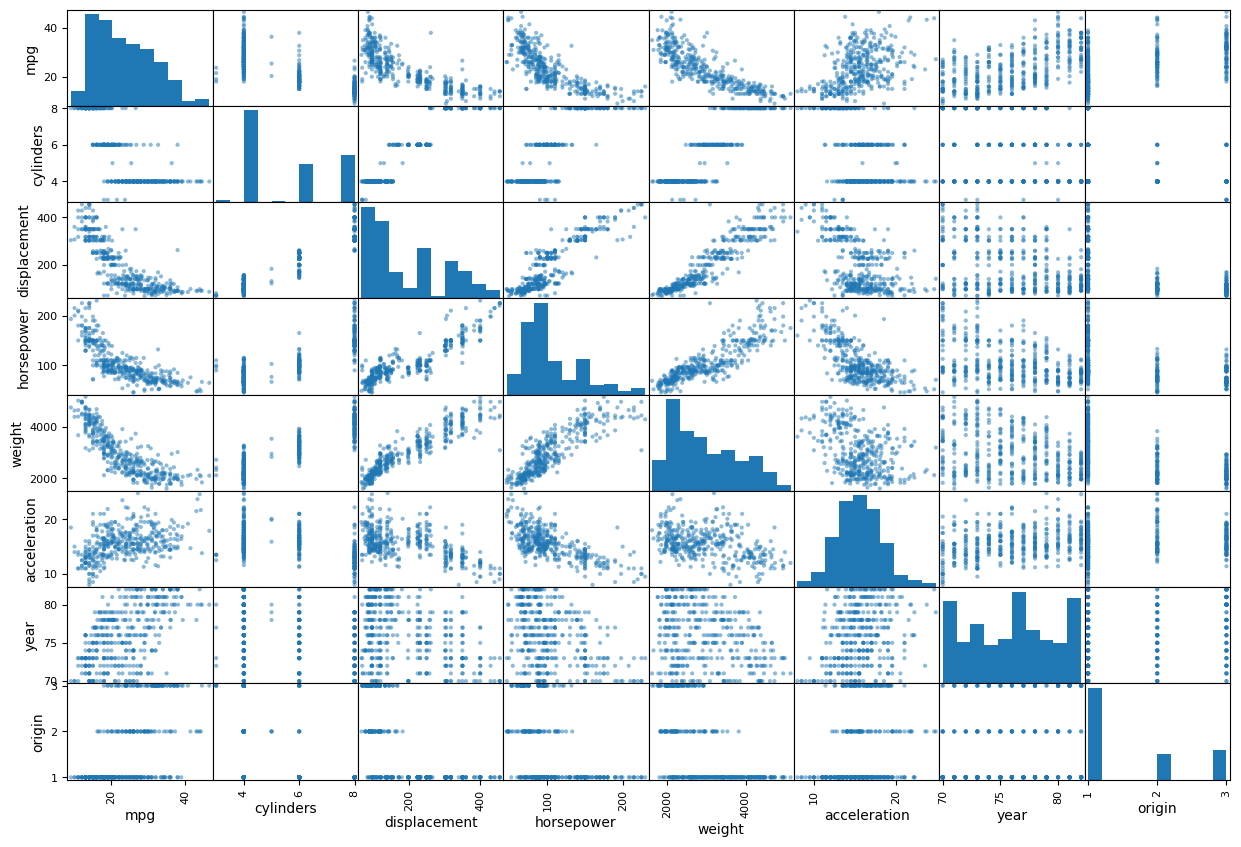

In [74]:
# Load the dataset and remove nulls and N/A values
auto = pd.read_csv('./data/Auto.csv')
auto.dropna(axis=0, how='any')
auto = auto[auto['horsepower'] != '?']
auto['horsepower'] = auto['horsepower'].astype('int64')

# Create a scatter matrix
pd.plotting.scatter_matrix(auto, figsize=(15,10));

### Part B

Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [75]:
quantitative = auto.describe().columns
auto[quantitative].corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


### Part C

Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:

1. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.
2. Which predictors appear to have a statistically significant relationship to the response?
3. What does the coefficient for the year variable suggest?

In [76]:
y = auto['mpg']
predictors = quantitative.drop('mpg')
x = sm.add_constant(auto[predictors])
model = sm.OLS(y, x, data=auto).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Wed, 16 Jul 2025   Prob (F-statistic):          2.04e-139
Time:                        19:17:43   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

c:\Users\water\anaconda3\envs\DSE6111\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['data']
  warnings.warn(msg, ValueWarning)


In [77]:
from ISLP.models import ModelSpec as MS

#### Type 1 ANOVA

In [78]:
# LINK TO REFERENCE: https://github.com/statsmodels/statsmodels/issues/8241
design = MS(predictors)
# THIS WAS FOUND HERE: https://islp.readthedocs.io/en/latest/models/spec.html
design.fit_transform(auto)
anova = sm.stats.anova_lm(*[sm.OLS(y, D).fit() for D in design.build_sequence(auto, anova_type='sequential')])
anova.index = design.names

anova

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
intercept,391.0,23818.993469,0.0,NaN,NaN,NaN
cylinders,390.0,9415.910391,1.0,14403.083079,1300.683788,2.806569e-126
displacement,389.0,8342.566366,1.0,1073.344025,96.929329,1.442524e-20
horsepower,388.0,7939.158297,1.0,403.408069,36.430140,3.700154e-09
weight,387.0,6963.433344,1.0,975.724953,88.113748,5.378297e-19
acceleration,386.0,6962.467273,1.0,0.966071,0.087242,7.678720e-01
year,385.0,4543.347025,1.0,2419.120249,218.460900,1.794078e-39
origin,384.0,4252.212530,1.0,291.134494,26.291171,4.665681e-07


#### Type 2 ANOVA

In [79]:
# CODE REFERENCE FOUND HERE: https://islp.readthedocs.io/en/latest/models/anova.html
dfs = []
for d in design.build_sequence(auto, anova_type='drop'):
    dfs.append(sm.stats.anova_lm(sm.OLS(y,d).fit(), model).iloc[1:])
df = pd.concat(dfs)
df.index = design.names
df

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
intercept,384.0,4252.21253,1.0,152.205951,13.745100,2.401841e-04
cylinders,384.0,4252.21253,1.0,25.791491,2.329125,1.277965e-01
displacement,384.0,4252.21253,1.0,77.612668,7.008884,8.444649e-03
horsepower,384.0,4252.21253,1.0,16.739754,1.511699,2.196328e-01
weight,384.0,4252.21253,1.0,1091.631693,98.580813,7.874953e-21
acceleration,384.0,4252.21253,1.0,7.358417,0.664509,4.154780e-01
year,384.0,4252.21253,1.0,2402.249906,216.937408,3.055983e-39
origin,384.0,4252.21253,1.0,291.134494,26.291171,4.665681e-07


### Part D

Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

### Part E

Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

### Part F

Try a few different transformations of the variables, such as log(X), √X, X2. Comment on your findings.

## Problem 10

This question should be answered using the Carseats data set.

### Part A

Fit a multiple regression model to predict Sales using Price,
Urban, and US.

### Part B

Provide an interpretation of each coefficient in the model. Be careful—some of the variables in the model are qualitative!

### Part C

Write out the model in equation form, being careful to handle the qualitative variables properly.

### Part D

For which of the predictors can you reject the null hypothesis H0:βj = 0?

### Part E

On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

### Part F

How well do the models in (a) and (e) fit the data?

### Part G

Using the model from (e), obtain 95% confidence intervals for the coefficient(s).

### Part H

Is there evidence of outliers or high leverage observations in the
model from (e)?

## Problem 14

This problem focuses on the collinearity problem.

### Part A

Perform the following commands in Python:

```python
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100) 
```

The last line corresponds to creating a linear model in which y is a function of x1 and x2. Write out the form of the linear model. What are the regression coefficients?


### Part B

What is the correlation between x1 and x2? Create a scatterplot displaying the relationship between the variables.

### Part C

Using this data, fit a least squares regression to predict y using x1 and x2. Describe the results obtained. What are ˆβ0, ˆβ1, andˆβ2? How do these relate to the true β0, β1, and β2? Can you reject the null hypothesis H0 : β1 = 0 ? How about the null hypothesis H0 : β2 = 0 ?

### Part D

Now fit a least squares regression to predict y using only x1. Comment on your results. Can you reject the null hypothesis H0 : β1 = 0 ?

### Part E

Now fit a least squares regression to predict y using only x2. Comment on your results. Can you reject the null hypothesis H0 : β1 = 0 ?

### Part F

Do the results obtained in (c)–(e) contradict each other? Explain your answer.

### Part G

Suppose we obtain one additional observation, which was unfortunately mismeasured. We use the function np.concatenate() to add this additional observation to each of x1, x2 and y.

```python
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]]) 
```

Re-fit the linear models from (c) to (e) using this new data. What effect does this new observation have on the each of the models? In each model, is this observation an outlier? A high-leverage point? Both?  Explain your answers.